### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## Chat myPDF : RAG with LLAMA, LangChain, Ollama, and FAISS Vector Store
### 1. Vector Stores and Retrievals

RAG PDF Dataset: https://github.com/laxmimerit/rag-dataset

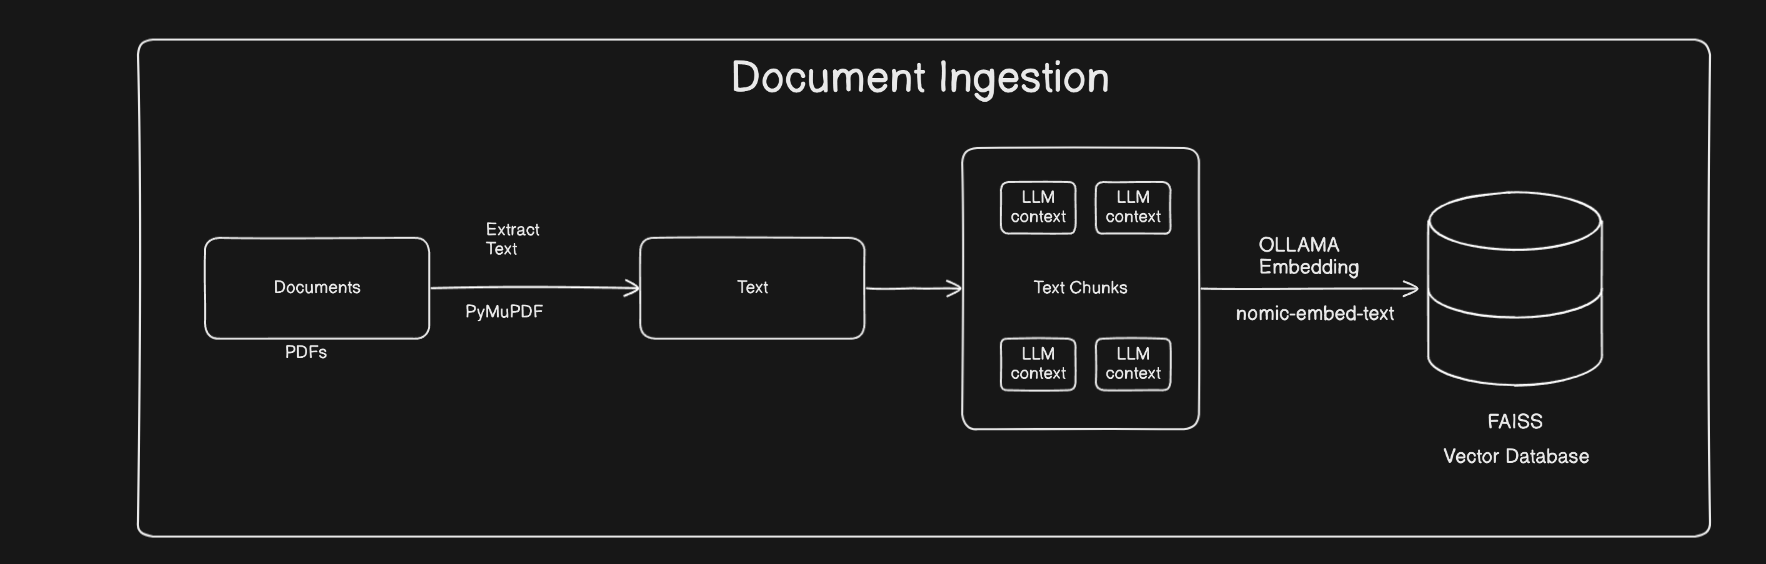

In [ ]:
# pip install faiss-cpu

In [1]:
import os
import warnings
from dotenv import load_dotenv

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

load_dotenv()

True

### Document Loader

In [2]:
### Read the list of PDFs in the dir

from langchain_community.document_loaders import PyMuPDFLoader
import os

pdfs = []
for root, dirs, files in os.walk("rag-dataset"):
    # print(root, dirs, files)
    for file in files:
        if file.endswith(".pdf"):
            pdfs.append(os.path.join(root, file))


In [3]:
docs = []
for pdf in pdfs:
    loader = PyMuPDFLoader(pdf)
    temp = loader.load()
    docs.extend(temp)

    # print(temp)
    # break

In [4]:
len(docs)

38

In [5]:
print(docs[0].page_content)
docs

International  Journal  of
Environmental Research
and Public Health
Review
Dietary Supplements—For Whom? The Current State of
Knowledge about the Health Effects of Selected
Supplement Use
Regina Ewa Wierzejska


Citation: Wierzejska, R.E. Dietary
Supplements—For Whom? The
Current State of Knowledge about the
Health Effects of Selected Supplement
Use. Int. J. Environ. Res. Public Health
2021, 18, 8897. https://doi.org/
10.3390/ijerph18178897
Academic Editor: Paul B. Tchounwou
Received: 15 July 2021
Accepted: 21 August 2021
Published: 24 August 2021
Publisher’s Note: MDPI stays neutral
with regard to jurisdictional claims in
published maps and institutional afﬁl-
iations.
Copyright: © 2021 by the author.
Licensee MDPI, Basel, Switzerland.
This article is an open access article
distributed
under
the
terms
and
conditions of the Creative Commons
Attribution (CC BY) license (https://
creativecommons.org/licenses/by/
4.0/).
Department of Nutrition and Nutritional Value of Food,

[Document(metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset/health supplements/1. dietary supplements - for whom.pdf', 'file_path': 'rag-dataset/health supplements/1. dietary supplements - for whom.pdf', 'total_pages': 17, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T11:37:54+00:00', 'trapped': '', 'modDate': 'D:20241021113754Z', 'creationDate': '', 'page': 0}, page_content='International  Journal  of\nEnvironmental Research\nand Public Health\nReview\nDietary Supplements—For Whom? The Current State of\nKnowledge about the Health Effects of Selected\nSupplement Use\nRegina Ewa Wierzejska\n\x01\x02\x03\x01\x04\x05\x06\x07\x08\x01\n\x01\x02\x03\x04\x05\x06\x07\nCitation: Wierzejska, R.E. Dietary\nSupplements—For Whom? The\nCurrent State of Knowledge about the\nHealth Effects of Selected Supplement\nUse. Int. J. Environ. Res. Public Health\n2021, 18, 8897. https://doi.org/\n10.3390/ijerph181

### Document Chunking

In [6]:
from langchain_text_splitters import  RecursiveCharacterTextSplitter


text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = text_splitter.split_documents(docs)

In [7]:
import tiktoken

encoding = tiktoken.encoding_for_model("gpt-4o-mini")
len(encoding.encode(chunks[0].page_content)), len(encoding.encode(chunks[1].page_content)), len(encoding.encode(docs[1].page_content))

(272, 192, 907)

### Document Vector Embedding

In [8]:
from langchain_ollama import OllamaEmbeddings

import faiss
from langchain_community.vectorstores import FAISS 
from langchain_community.docstore.in_memory import InMemoryDocstore

In [9]:
embeddings = OllamaEmbeddings(model='nomic-embed-text', base_url='http://localhost:11434')

In [10]:
vector = embeddings.embed_query("Hello World")

In [11]:
len(vector)
index = faiss.IndexFlatL2(len(vector))
index.ntotal, index.d

(0, 768)

In [12]:
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [13]:
vector_store.index.ntotal, vector_store.index.d

(0, 768)

In [14]:
ids = vector_store.add_documents(documents=chunks)

In [15]:
len(ids), vector_store.index.ntotal

(201, 201)

In [16]:
ids
vector_store.index_to_docstore_id


{0: 'a258b982-ea36-43d7-b4a0-2b74fb0ffe7b',
 1: '4d573c75-5cf4-4eaa-b347-67fc66076e88',
 2: '64c30e09-0470-4927-95b5-ba904d3ed736',
 3: '07038460-d670-44cc-b1b0-b42c545a3241',
 4: '1d54f568-f869-4192-9dd3-991478fd5cae',
 5: '4143ff8f-def0-4d70-aa45-404da3fef129',
 6: '99ceac13-70aa-4f30-a3c6-953ddabfd54f',
 7: 'd56995d4-6acf-43e5-ba86-285a7be0ca66',
 8: 'e99b958e-96a8-49c3-8b7c-c767a33f5858',
 9: '0c359848-6c76-4fb6-b184-028fbb4170cc',
 10: '735f19b8-60a4-49c0-97b7-edbed5b138d6',
 11: '15dce0f8-1ae8-469d-bb2e-3014b348a586',
 12: '4876ad91-4aec-4e3b-8c57-13fb1266503d',
 13: '18930bb8-5ed9-4a54-a2e5-9ed6a5fee1c8',
 14: '812afb4a-772c-47f4-bfaf-dbd53c457a33',
 15: '770d4e5f-1798-429d-9237-302950a7d812',
 16: '22583784-6589-4b5e-82f8-364f81c38ab4',
 17: '336abd0c-8a34-4834-8f3f-08f1eeb22dfd',
 18: '0c3fa5cc-5e23-4489-b4a5-8b79eced0436',
 19: '03879e2c-9710-4e26-84b7-319ddf6bfbb0',
 20: '1aea7bfd-81e9-4ae9-b68f-dd114b9d5087',
 21: '4a42dcdb-3354-47aa-adb0-192ec16034eb',
 22: '4b39c5ed-140e-

In [17]:
### Retreival
question = "how to gain muscle mass?"
docs = vector_store.search(query=question, k=5, search_type="similarity")

In [18]:
docs

[Document(id='2eed1e91-10e4-4834-bfe2-08cddc47021a', metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset/health supplements/1. dietary supplements - for whom.pdf', 'file_path': 'rag-dataset/health supplements/1. dietary supplements - for whom.pdf', 'total_pages': 17, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T11:37:54+00:00', 'trapped': '', 'modDate': 'D:20241021113754Z', 'creationDate': '', 'page': 12}, page_content='Int. J. Environ. Res. Public Health 2021, 18, 8897\n13 of 24\n3.3. Dietary Supplements and Weight Loss\nThe number of people with excessive weight continues to rise, and ﬁghting obesity\nhas become one of the greatest challenges of contemporary medicine. A person wishing to\nlose weight needs to undertake several difﬁcult life-changes and practice them consistently\n(diet, physical activity, addiction-free). Meanwhile dietary supplements are presented as\na compelling altern

In [19]:
db_name = "health_supplements"

vector_store.save_local(db_name)